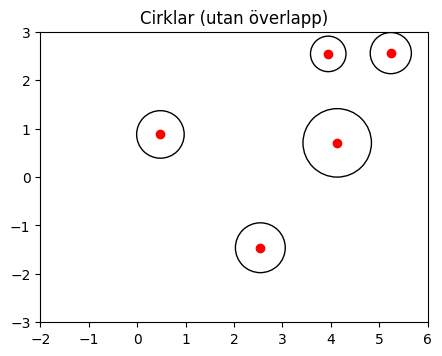

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------
# Generera cirklar (utan överlapp)
# -----------------------
num_circles = 5
xmin, xmax = -2, 6
ymin, ymax = -3, 3
r_min, r_max = 0.3, 0.8

circles = []

def is_overlapping(x, y, r, circles):
    for (cx, cy, cr) in circles:
        if np.hypot(x - cx, y - cy) < (r + cr):
            return True
    return False

while len(circles) < num_circles:
    r = random.uniform(r_min, r_max)
    x = random.uniform(xmin + r, xmax - r)
    y = random.uniform(ymin + r, ymax - r)
    
    if not is_overlapping(x, y, r, circles):
        circles.append((x, y, r))

# -----------------------
# Plot cirklar
# -----------------------
fig, ax = plt.subplots(figsize=(5,5))

for (x, y, r) in circles:
    circ = plt.Circle((x, y), r, fill=False)
    ax.add_patch(circ)
    ax.plot(x, y, 'ro')

ax.set_aspect('equal')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("Cirklar (utan överlapp)")

plt.show()

# Viktigt: cirklarna ligger kvar i variabeln 'circles'

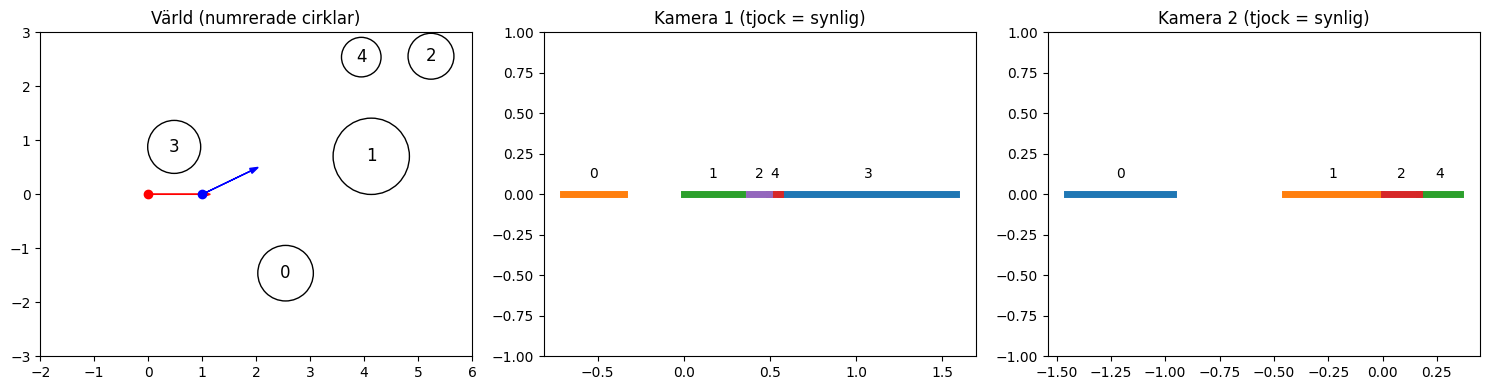

Synliga cirklar kamera 1: [3, 0, 1, 4, 2]
Synliga cirklar kamera 2: [0, 1, 4, 2]
Kamera 2 vinkel (rad): 0.44863573385016364
Kamera 1 depths:
0 2.544383124073168
1 4.1313759500132905
2 5.237642405245861
3 0.48134739580033603
4 3.9463832476034835


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(10)

# -----------------------
# Kamera-klass
# -----------------------
class Camera2D:
    def __init__(self, position, theta):
        self.c = np.array(position)
        self.theta = theta
        self.dir = np.array([np.cos(theta), np.sin(theta)])
        #self.right = np.array([-np.sin(theta), np.cos(theta)])
        self.right = np.array([np.sin(theta), -np.cos(theta)])

# Kamera 1
cam1 = Camera2D((0, 0), 0.0)

# Kamera 2
theta2 = random.uniform(-np.pi, np.pi)
cam2 = Camera2D((1, 0), theta2)

# -----------------------
# Projektion via tangenter
# -----------------------
def project_circle(cam, circle):
    m = np.array(circle[:2])
    R = circle[2]
    
    v = m - cam.c
    d = np.linalg.norm(v)
    
    if d <= R:
        return None
    
    alpha = np.arctan2(v[1], v[0])
    beta = np.arcsin(R / d)
    
    theta1 = alpha - beta
    theta2 = alpha + beta
    
    rel1 = cam.theta - theta1
    rel2 = cam.theta - theta2
    
    # NORMALISERA till [-pi, pi]
    def wrap(a):
        return (a + np.pi) % (2*np.pi) - np.pi
    
    rel1 = wrap(rel1)
    rel2 = wrap(rel2)
    
    return sorted([rel1, rel2]), d


# -----------------------
# Synlighetsberäkning (1D ocklusion)
# -----------------------
def subtract_interval(interval, covered):
    """Returnerar delar av interval som INTE är täckta"""
    umin, umax = interval
    segments = [(umin, umax)]
    
    for cmin, cmax in covered:
        new_segments = []
        for smin, smax in segments:
            # ingen överlapp
            if smax <= cmin or smin >= cmax:
                new_segments.append((smin, smax))
            else:
                # vänster bit
                if smin < cmin:
                    new_segments.append((smin, cmin))
                # höger bit
                if smax > cmax:
                    new_segments.append((cmax, smax))
        segments = new_segments
    
    return segments


def compute_visibility(cam, circles):
    projections = []
    
    for i, c in enumerate(circles):
        res = project_circle(cam, c)
        if res is not None:
            interval, depth = res
            
            # filtrera bort saker bakom kameran
            m = np.array(c[:2])
            if np.dot(m - cam.c, cam.dir) <= 0:
                continue
            
            projections.append((i, interval[0], interval[1], depth))
    
    # sortera närmast först
    projections.sort(key=lambda x: x[3])
    
    visible = []
    covered = []
    
    for idx, umin, umax, d in projections:
        remaining = subtract_interval((umin, umax), covered)
        
        if remaining:
            for seg in remaining:
                visible.append((idx, seg[0], seg[1]))
                covered.append(seg)
    
    return projections, visible


proj1_all, vis1 = compute_visibility(cam1, circles)
proj2_all, vis2 = compute_visibility(cam2, circles)

# -----------------------
# Plot
# -----------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# --- Värld ---
ax = axs[0]
for i, (x, y, r) in enumerate(circles):
    circ = plt.Circle((x, y), r, fill=False)
    ax.add_patch(circ)
    ax.text(x, y, str(i), fontsize=12, ha='center', va='center')

def draw_camera(ax, cam, color):
    c = cam.c
    d = cam.dir
    ax.plot(c[0], c[1], 'o', color=color)
    ax.arrow(c[0], c[1], d[0], d[1], head_width=0.1, color=color)

draw_camera(ax, cam1, 'red')
draw_camera(ax, cam2, 'blue')

ax.set_aspect('equal')
ax.set_title("Värld (numrerade cirklar)")
ax.set_xlim(-2, 6)
ax.set_ylim(-3, 3)

# --- Kamera 1 ---
ax = axs[1]
for idx, umin, umax, d in proj1_all:
    ax.plot([umin, umax], [0, 0], color='gray', linewidth=2)

for idx, umin, umax in vis1:
    ax.plot([umin, umax], [0, 0], linewidth=5)
    ax.text((umin+umax)/2, 0.1, str(idx), ha='center')

ax.set_title("Kamera 1 (tjock = synlig)")
ax.set_ylim(-1, 1)

# --- Kamera 2 ---
ax = axs[2]
for idx, umin, umax, d in proj2_all:
    ax.plot([umin, umax], [0, 0], color='gray', linewidth=2)

for idx, umin, umax in vis2:
    ax.plot([umin, umax], [0, 0], linewidth=5)
    ax.text((umin+umax)/2, 0.1, str(idx), ha='center')

ax.set_title("Kamera 2 (tjock = synlig)")
ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

# -----------------------
# Print resultat
# -----------------------
print("Synliga cirklar kamera 1:", [idx for idx, _, _ in vis1])
print("Synliga cirklar kamera 2:", [idx for idx, _, _ in vis2])
print("Kamera 2 vinkel (rad):", theta2)

print("Kamera 1 depths:")
for i, c in enumerate(circles):
    m = np.array(c[:2])
    depth = np.dot(m - cam1.c, cam1.dir)
    print(i, depth)